# Lezione 7.2 - Riconoscimento Cifre MNIST

In questa lezione costruiremo una **semplice rete neurale convoluzionale (CNN o MLP)** per riconoscere cifre scritte a mano.

## Cosa faremo:

1. Scaricare il dataset MNIST
2. Visualizzare un'immagine
3. Visualizzare un batch di immagini
4. Dividere il dataset (train/validation)
5. Creare batch di dati
6. Costruire un MLP semplice
7. Addestrare la rete
8. Valutare i risultati

---

## Importare le Librerie e Scaricare il Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# Scarichiamo il dataset MNIST
transform = transforms.ToTensor()  # Converte immagini in tensori

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Dataset scaricato!")
print(f"Training: {len(train_data)} immagini")
print(f"Test: {len(test_data)} immagini")

Dataset scaricato!
Training: 60000 immagini
Test: 10000 immagini


---

## Visualizzare una Singola Immagine

Forma immagine: torch.Size([1, 28, 28])
Label: 5
Range valori: [0.00, 1.00]


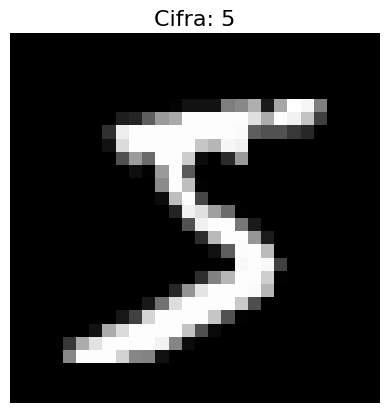

In [3]:
# Prendiamo la prima immagine
image, label = train_data[0]

print(f"Forma immagine: {image.shape}")  # [1, 28, 28] = [canali, altezza, larghezza
print(f"Label: {label}")
print(f"Range valori: [{image.min():.2f}, {image.max():.2f}]")

# Visualizziamo
plt.figure()
plt.imshow(image.squeeze(), cmap='gray')  # squeeze rimuove la dimensione canale
plt.title(f'Cifra: {label}', fontsize=16)
plt.axis('off')
plt.show()

---

## Visualizzare un Batch di Immagini

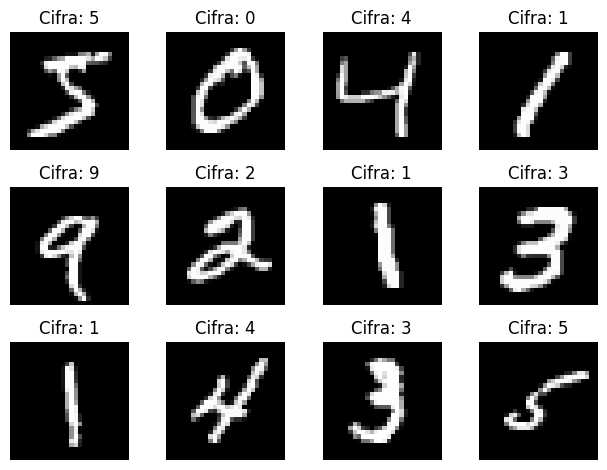

In [5]:
# Visualizziamo 12 immagini
fig, axes = plt.subplots(3, 4)

for i, ax in enumerate(axes.flat): # Restituisce sia l'indice (i) che l'elemento (ax)
    # Invece di axes[0,0], axes[0,1], ..., axes[2,3]
    # Diventa: axes[0], axes[1], ..., axes[11]
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Cifra: {label}')
    ax.axis('off')

plt.tight_layout() # Aggiusta automaticamente la spaziatura tra i subplot
plt.show()

---

## Dividere il Dataset (Train/Validation)

Dividiamo il training set in due parti:
- **Train**: per addestrare il modello (80%)
- **Validation**: per valutare durante l'addestramento (20%)

In [4]:
# Dividiamo: 80% train, 20% validation
train_size = int(0.8 * len(train_data)) #training size
val_size = len(train_data) - train_size # vlaidation size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

print(f"Dataset diviso")
print(f"Training: {len(train_dataset)} immagini")
print(f"Validation: {len(val_dataset)} immagini")
print(f"Test: {len(test_data)} immagini")

Dataset diviso
Training: 48000 immagini
Validation: 12000 immagini
Test: 10000 immagini


---

## Creare i Batch

I **batch** sono gruppi di immagini che processare insieme. Questo rende l'addestramento più veloce ed efficiente

In [5]:
batch_size = 64

# Creiamo i DataLoader (gestiscono i batch automaticamente)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Batch creati")
print(f"Batch size: {batch_size}")
print(f"Numero batch training: {len(train_loader)}")
print(f"Numero batch validation: {len(val_loader)}")

# Vediamo com'è fatto un batch
images_batch, labels_batch = next(iter(train_loader))
print(f"\nForma di un batch di immagini: {images_batch.shape}")
print(f"Forma di un batch di label: {labels_batch.shape}")

Batch creati
Batch size: 64
Numero batch training: 750
Numero batch validation: 188

Forma di un batch di immagini: torch.Size([64, 1, 28, 28])
Forma di un batch di label: torch.Size([64])


### Visualizziamo un Batch Completo SKIPPARE

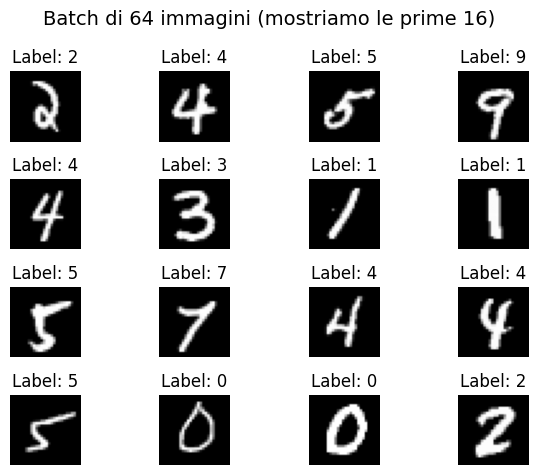

In [ ]:
# Visualizziamo le prime 16 immagini del batch
fig, axes = plt.subplots(4, 4)

for i, ax in enumerate(axes.flat):
    if i < len(images_batch):
        ax.imshow(images_batch[i].squeeze(), cmap='gray')
        ax.set_title(f'Label: {labels_batch[i]}')
        ax.axis('off')

plt.suptitle(f'Batch di {batch_size} immagini (mostriamo le prime 16)', fontsize=14)
plt.tight_layout()
plt.show()

---

## Creare il Modello (MLP Semplice)

Un **MLP (Multi-Layer Perceptron)** è una rete neurale semplice composta da layer "fully connected".

**Architettura**:
- Input: 784 pixel (28×28 appiattiti)
- Hidden layer 1: 128 neuroni
- Hidden layer 2: 64 neuroni
- Output: 10 neuroni (uno per cifra 0-9)

In [6]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        
        self.flatten = nn.Flatten() # Appiattisce l'input
        # Layer della rete
        self.fc1 = nn.Linear(28*28, 128)  # 784 -> 128
        self.fc2 = nn.Linear(128, 64)     # 128 -> 64
        self.fc3 = nn.Linear(64, 10)      # 64 -> 10
        self.relu = nn.ReLU() # F di attivazione
        # fc = fully connected

    # Metodo obbligatorio
    def forward(self, x):
        # Appiattimento: da [batch, 1, 28, 28] a [batch, 784]
        x = self.flatten(x)
        
        # Layer 1
        x = self.fc1(x)
        x = self.relu(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.relu(x)
        
        # Layer output
        x = self.fc3(x)
        
        return x

# Creiamo il modello
model = SimpleMLP() # istanziamo la classe
print("Modello creato")
print(model)

# Contiamo i parametri
total_params = sum(p.numel() for p in model.parameters())
print(f"\nParametri totali: {total_params:,}")

Modello creato
SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

Parametri totali: 109,386


---

## Addestrare il Modello

Ora alleniamo la rete! Il training è un ciclo che:
1. Prende un batch di dati
2. Fa una predizione (forward)
3. Calcola l'errore (loss)
4. Aggiorna i pesi (backward)

In [7]:
# Configurazione
criterion = nn.CrossEntropyLoss()  # Funzione di perdita
# Come funziona?
# Prende i 10 punteggi "grezzi" (logits) prodotti dal modello.
# Li converte internamente in probabilità (usando una funzione chiamata Softmax).
# Confronta queste probabilità con la risposta corretta (la label reale).
# Calcola un singolo valore (la loss) che è tanto più alto quanto più la probabilità assegnata alla classe giusta è bassa.
# L'obiettivo dell'addestramento sarà minimizzare questo valore.


# Ottimizzatore con momentum
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# Alternativa senza momentum, spesso migliore:
# optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Device: {device}")
print(f"Loss: CrossEntropyLoss")
print(f"Optimizer: SGD (lr=0.01, momentum=0.9)")
print(f"\nInizio training...\n")

Device: cuda
Loss: CrossEntropyLoss
Optimizer: SGD (lr=0.01, momentum=0.9)

Inizio training...



In [8]:
# 4. Training Loop (Addestramento)
print("Inizio addestramento...")

# Ciclo per 5 epoche (volte in cui vediamo tutto il dataset)
for epoch in range(5):  
    # Iteriamo su ogni batch del DataLoader
    for images, labels in train_loader:
        # Spostiamo i dati sul device (GPU o CPU)
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass: calcoliamo le predizioni del modello
        outputs = model(images)
        
        # Calcoliamo l'errore (loss) tra predizioni e label vere
        loss = criterion(outputs, labels)
        
        # Backward pass e ottimizzazione
        optimizer.zero_grad()  # Azzera i gradienti vecchi (fondamentale!)
        loss.backward()        # Calcola i nuovi gradienti (backpropagation)
        optimizer.step()       # Aggiorna i pesi della rete usando l'ottimizzatore

    # Stampiamo la loss alla fine di ogni epoca
    print(f'Epoca {epoch+1}, Loss finale batch: {loss.item():.4f}')

print("Addestramento completato.")

Inizio addestramento...
Epoca 1, Loss finale batch: 0.3551
Epoca 1, Loss finale batch: 0.3551
Epoca 2, Loss finale batch: 0.1883
Epoca 2, Loss finale batch: 0.1883
Epoca 3, Loss finale batch: 0.1397
Epoca 3, Loss finale batch: 0.1397
Epoca 4, Loss finale batch: 0.0644
Epoca 4, Loss finale batch: 0.0644
Epoca 5, Loss finale batch: 0.0169
Addestramento completato.
Epoca 5, Loss finale batch: 0.0169
Addestramento completato.


In [ ]:
# 5. Test su una singola immagine
# Carichiamo i dati di test (quelli mai visti durante il training)
test_data = datasets.MNIST('./data', train=False, transform=transforms.ToTensor())

# Prendiamo la prima immagine e la sua etichetta reale
img, label = test_data[0]

# La rete vuole un batch, quindi aggiungiamo una dimensione fittizia: (1, 1, 28, 28)
output = model(img.unsqueeze(0).to(device)) # Spostiamo anche l'immagine sul device corretto

# La predizione è l'indice con il valore più alto
prediction = output.argmax().item()

print(f"Il numero vero è: {label}")
print(f"La rete ha predetto: {prediction}")

---

## Valutare i Risultati

### Grafici di Training

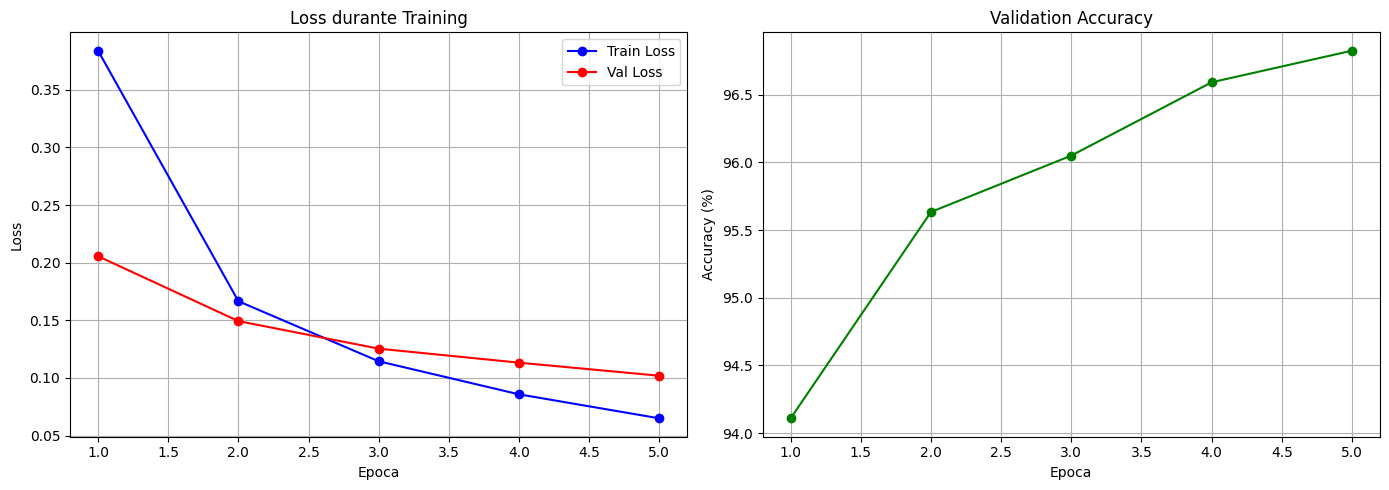

Loss finale (train): 0.0649
Loss finale (validation): 0.1019
Accuracy finale (validation): 96.83%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico Loss
epochs = range(1, num_epochs + 1)
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss durante Training')
ax1.legend()
ax1.grid(True)

# Grafico Accuracy
ax2.plot(epochs, val_accuracies, 'g-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Loss finale (train): {train_losses[-1]:.4f}")
print(f"Loss finale (validation): {val_losses[-1]:.4f}")
print(f"Accuracy finale (validation): {val_accuracies[-1]:.2f}%")

### Test sul Test Set

In [18]:
# Testiamo sul test set (dati mai visti!)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Predizioni corrette: {correct}/{total}")

Test Accuracy: 97.39%
Predizioni corrette: 9739/10000


### Visualizziamo Alcune Predizioni

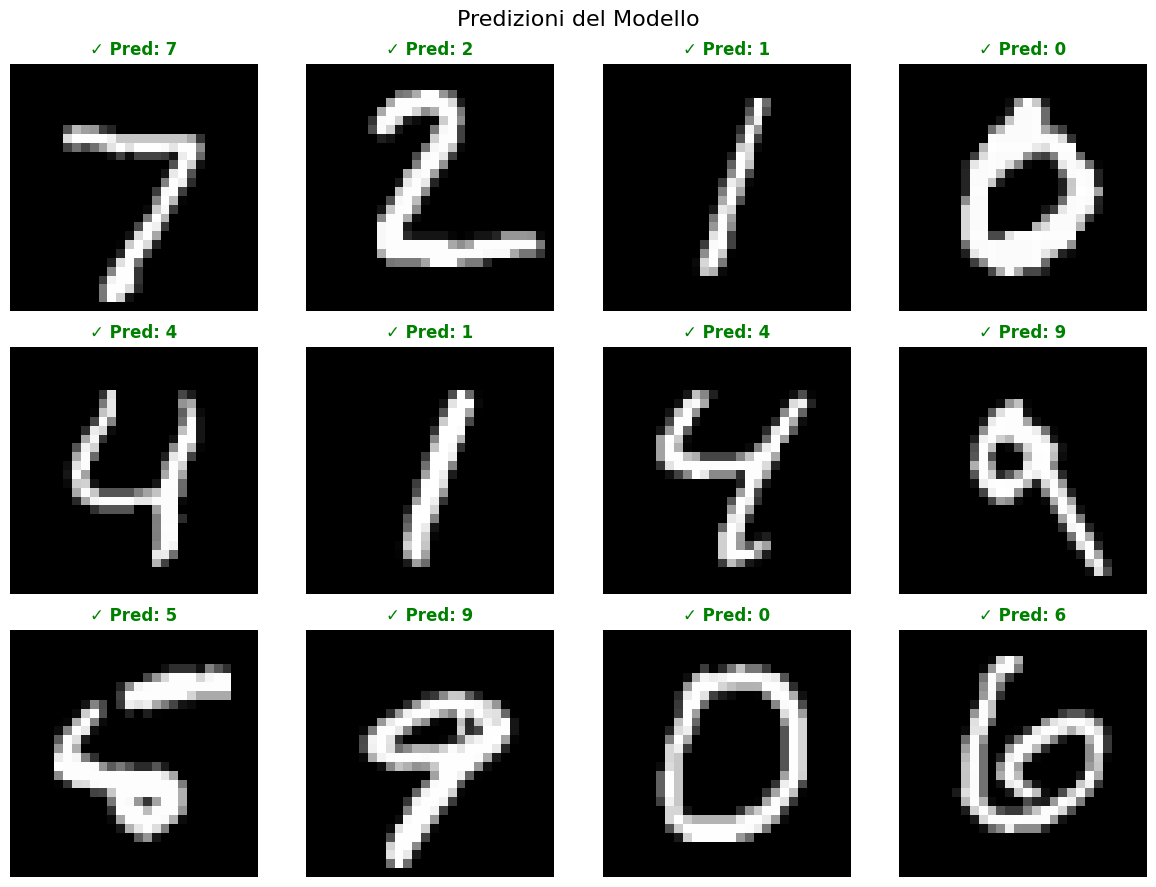

In [19]:
# Prendiamo un batch dal test set
images, labels = next(iter(test_loader))
images = images.to(device)

# Facciamo le predizioni
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Visualizziamo 12 esempi
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()
    true_label = labels[i].item()
    pred_label = predicted[i].cpu().item()
    
    ax.imshow(img, cmap='gray')
    
    # Verde se corretto, rosso se sbagliato
    if true_label == pred_label:
        color = 'green'
        title = f'✓ Pred: {pred_label}'
    else:
        color = 'red'
        title = f'✗ Pred: {pred_label} (Vero: {true_label})'
    
    ax.set_title(title, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predizioni del Modello', fontsize=16)
plt.tight_layout()
plt.show()